## Part A - Asphalt Crack Image Classification

In [3]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
DATASET_PATH = "dataset"

CRACK_PATH = os.path.join(DATASET_PATH, "Crack")
NON_CRACK_PATH = os.path.join(DATASET_PATH, "Non-Crack")

print("Crack folder:", CRACK_PATH)
print("Non-crack folder:", NON_CRACK_PATH)

Crack folder: dataset\Crack
Non-crack folder: dataset\Non-Crack


count the images

In [9]:
image_extensions = (".jpg", ".jpeg", ".png", ".bmp")

crack_images = [
    file for file in os.listdir(CRACK_PATH)
    if file.lower().endswith(image_extensions)
]

non_crack_images = [
    file for file in os.listdir(NON_CRACK_PATH)
    if file.lower().endswith(image_extensions)
]

print("Number of crack images:", len(crack_images))
print("Number of non-crack images:", len(non_crack_images))
print("Total images:", len(crack_images) + len(non_crack_images))

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'dataset\\Non-Crack'

In [6]:
import os

print("Folders inside dataset:")
print(os.listdir("dataset"))

Folders inside dataset:
['crack']


In [10]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nContents of current folder:")
print(os.listdir("."))

print("\nContents of dataset folder:")
print(os.listdir("dataset"))

Current working directory:
c:\Users\Yashish\OneDrive\Desktop\202618019_JayeshHedaoo_DS605\202618019_LAB06

Contents of current folder:
['dataset', 'data_set', 'lab06.ipynb', 'output']

Contents of dataset folder:
['Crack']


In [12]:
import os

print(os.listdir("data_set"))

['Non-crack']


In [13]:
import os

print(os.listdir("dataset"))

['Crack']


In [14]:
print(os.listdir("dataset"))

['Crack', 'Non-Crack']


In [15]:
DATASET_PATH = "dataset"

CRACK_PATH = os.path.join(DATASET_PATH, "Crack")
NON_CRACK_PATH = os.path.join(DATASET_PATH, "Non-Crack")

print("Crack path:", CRACK_PATH)
print("Non-crack path:", NON_CRACK_PATH)

Crack path: dataset\Crack
Non-crack path: dataset\Non-Crack


In [16]:
image_extensions = (".jpg", ".jpeg", ".png", ".bmp")

crack_images = [
    file for file in os.listdir(CRACK_PATH)
    if file.lower().endswith(image_extensions)
]

non_crack_images = [
    file for file in os.listdir(NON_CRACK_PATH)
    if file.lower().endswith(image_extensions)
]

print("Number of crack images:", len(crack_images))
print("Number of non-crack images:", len(non_crack_images))
print("Total images:", len(crack_images) + len(non_crack_images))

Number of crack images: 199
Number of non-crack images: 199
Total images: 398


In [17]:
# Select the first crack image
sample_filename = crack_images[0]
sample_path = os.path.join(CRACK_PATH, sample_filename)

# Read the image
sample_image = cv2.imread(sample_path)

print("Image filename:", sample_filename)
print("Original image shape:", sample_image.shape)
print("Height:", sample_image.shape[0])
print("Width:", sample_image.shape[1])
print("Channels:", sample_image.shape[2])# Select the first crack image
sample_filename = crack_images[0]
sample_path = os.path.join(CRACK_PATH, sample_filename)

# Read the image
sample_image = cv2.imread(sample_path)

print("Image filename:", sample_filename)
print("Original image shape:", sample_image.shape)
print("Height:", sample_image.shape[0])
print("Width:", sample_image.shape[1])
print("Channels:", sample_image.shape[2])

Image filename: IMG_20180705_130729936 resized_448 (1).jpg
Original image shape: (448, 448, 3)
Height: 448
Width: 448
Channels: 3
Image filename: IMG_20180705_130729936 resized_448 (1).jpg
Original image shape: (448, 448, 3)
Height: 448
Width: 448
Channels: 3


Resize the image

In [18]:
IMG_SIZE = (128, 128)

resized_image = cv2.resize(sample_image, IMG_SIZE)

print("Resized image shape:", resized_image.shape)

Resized image shape: (128, 128, 3)


Convert to grayscale

In [19]:
gray_image = cv2.cvtColor(resized_image, cv2.COLOR_BGR2GRAY)

print("Grayscale image shape:", gray_image.shape)

Grayscale image shape: (128, 128)


Display all three

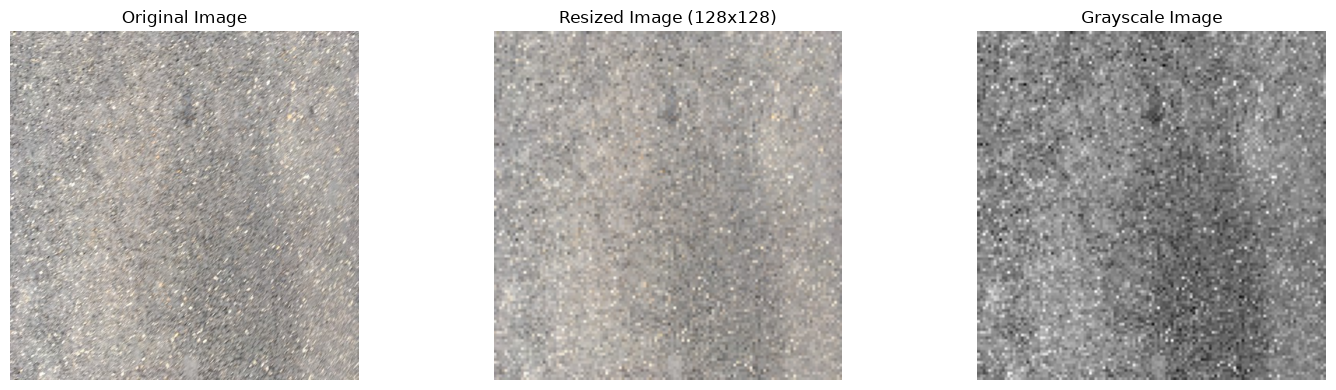

In [20]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(sample_image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(resized_image, cv2.COLOR_BGR2RGB))
plt.title("Resized Image (128x128)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(gray_image, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.tight_layout()
plt.show()

Create the feature extraction function

In [22]:
def extract_image_features(image_path):
    # Read image
    image = cv2.imread(image_path)

    # Resize image
    image = cv2.resize(image, IMG_SIZE)

    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Intensity-based features
    
    mean_brightness = np.mean(gray)

    contrast = np.std(gray)

    dark_pixel_ratio = np.mean(gray < 50)

    bright_pixel_ratio = np.mean(gray > 200)

    min_intensity = np.min(gray)

    max_intensity = np.max(gray)

    
    # Canny edge features
    

    edges = cv2.Canny(gray, 100, 200)

    edge_count = np.sum(edges > 0)

    total_pixels = gray.shape[0] * gray.shape[1]

    edge_density = edge_count / total_pixels

    # Return all features
    return {
        "mean_brightness": mean_brightness,
        "contrast": contrast,
        "dark_pixel_ratio": dark_pixel_ratio,
        "bright_pixel_ratio": bright_pixel_ratio,
        "min_intensity": min_intensity,
        "max_intensity": max_intensity,
        "edge_count": edge_count,
        "edge_density": edge_density
    }

In [23]:
sample_features = extract_image_features(sample_path)

print("Features extracted from sample image:")
for feature, value in sample_features.items():
    print(f"{feature}: {value}")

Features extracted from sample image:
mean_brightness: 165.1109619140625
contrast: 20.232830948629385
dark_pixel_ratio: 0.0
bright_pixel_ratio: 0.0439453125
min_intensity: 74
max_intensity: 250
edge_count: 3341
edge_density: 0.20391845703125


Creating features for all images

In [24]:
all_features = []

for filename in crack_images:
    image_path = os.path.join(CRACK_PATH, filename)

    features = extract_image_features(image_path)
    features["image_name"] = filename
    features["label"] = "Crack"

    all_features.append(features)


# Process non-crack images
for filename in non_crack_images:
    image_path = os.path.join(NON_CRACK_PATH, filename)

    features = extract_image_features(image_path)
    features["image_name"] = filename
    features["label"] = "Non-Crack"

    all_features.append(features)


print("Total feature rows:", len(all_features))

Total feature rows: 398


In [25]:
features_df = pd.DataFrame(all_features)

features_df.head()

,mean_brightness,contrast,dark_pixel_ratio,bright_pixel_ratio,min_intensity,max_intensity,edge_count,edge_density,image_name,label
0,165.110962,20.232831,0.000000,0.043945,74,250,3341,0.203918,IMG_20180705_130729936 resized_448 (1).jpg,Crack
1,155.132568,16.395432,0.000000,0.005981,91,242,1281,0.078186,IMG_20180705_130731751 resized_448 (1).jpg,Crack
2,150.409058,31.669253,0.000061,0.051758,47,252,5805,0.354309,IMG_20180705_130732496 resized_448 (1).jpg,Crack
3,164.683228,28.874364,0.000732,0.088623,32,253,5618,0.342896,IMG_20180705_130732993 resized_448 (1).jpg,Crack
4,170.836914,17.604928,0.000000,0.050537,96,252,2280,0.139160,IMG_20180705_130733329 resized_448 (1).jpg,Crack


In [26]:
features_df.to_csv("output/image_features.csv", index=False)

print("Feature table saved successfully.")

Feature table saved successfully.


Create a Canny-edge visualization

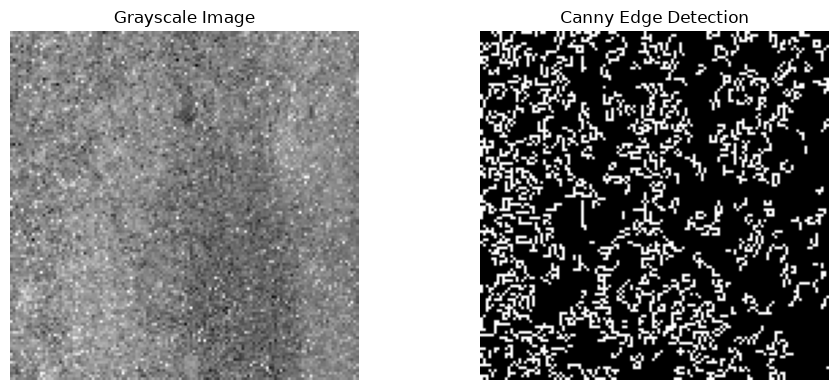

In [27]:
# Apply Canny edge detection to the sample grayscale image
edges = cv2.Canny(gray_image, 100, 200)

# Display grayscale and Canny edge image
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(gray_image, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(edges, cmap="gray")
plt.title("Canny Edge Detection")
plt.axis("off")

plt.tight_layout()
plt.show()

In [28]:
# Save the Canny edge image
canny_output_path = "output/sample_canny_edges.png"

cv2.imwrite(canny_output_path, edges)

print("Canny edge image saved to:", canny_output_path)

Canny edge image saved to: output/sample_canny_edges.png


In [29]:
gray_output_path = "output/sample_grayscale.png"

cv2.imwrite(gray_output_path, gray_image)

print("Grayscale image saved to:", gray_output_path)

Grayscale image saved to: output/sample_grayscale.png


In [30]:
features_df.shape

(398, 10)

In [31]:
features_df.head()

,mean_brightness,contrast,dark_pixel_ratio,bright_pixel_ratio,min_intensity,max_intensity,edge_count,edge_density,image_name,label
0,165.110962,20.232831,0.000000,0.043945,74,250,3341,0.203918,IMG_20180705_130729936 resized_448 (1).jpg,Crack
1,155.132568,16.395432,0.000000,0.005981,91,242,1281,0.078186,IMG_20180705_130731751 resized_448 (1).jpg,Crack
2,150.409058,31.669253,0.000061,0.051758,47,252,5805,0.354309,IMG_20180705_130732496 resized_448 (1).jpg,Crack
3,164.683228,28.874364,0.000732,0.088623,32,253,5618,0.342896,IMG_20180705_130732993 resized_448 (1).jpg,Crack
4,170.836914,17.604928,0.000000,0.050537,96,252,2280,0.139160,IMG_20180705_130733329 resized_448 (1).jpg,Crack


In [32]:
features_df["label"].value_counts()

label
Crack        199
Non-Crack    199
Name: count, dtype: int64

In [33]:
print("Feature table shape:", features_df.shape)

Feature table shape: (398, 10)


In [34]:
print(features_df.isnull().sum())

mean_brightness       0
contrast              0
dark_pixel_ratio      0
bright_pixel_ratio    0
min_intensity         0
max_intensity         0
edge_count            0
edge_density          0
image_name            0
label                 0
dtype: int64


Prepare X and y

In [35]:
# Separate features and labels

X = features_df.drop(columns=["image_name", "label"])
y = features_df["label"]

print("Feature shape:", X.shape)
print("Label shape:", y.shape)
print("\nFeature columns:")
print(X.columns.tolist())

Feature shape: (398, 8)
Label shape: (398,)

Feature columns:
['mean_brightness', 'contrast', 'dark_pixel_ratio', 'bright_pixel_ratio', 'min_intensity', 'max_intensity', 'edge_count', 'edge_density']


In [36]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Classes:", label_encoder.classes_)
print("Encoded labels:", np.unique(y_encoded))

Classes: ['Crack' 'Non-Crack']
Encoded labels: [0 1]


Train-test split

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 318
Testing samples: 80


Scaling the features

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


Training the model

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    "SVM": SVC(kernel="rbf", random_state=42)
}

print("Models created:")
for model_name in models:
    print("-", model_name)

Models created:
- Logistic Regression
- Random Forest
- SVM


Measure training and prediction time

In [40]:
import time

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

results = []
confusion_matrices = {}

for model_name, model in models.items():

    # Training time
    start_train = time.perf_counter()
    model.fit(X_train_scaled, y_train)
    train_time = time.perf_counter() - start_train

    # Prediction time
    start_pred = time.perf_counter()
    y_pred = model.predict(X_test_scaled)
    prediction_time = time.perf_counter() - start_pred

    # Evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Training Time (s)": train_time,
        "Prediction Time (s)": prediction_time
    })

    confusion_matrices[model_name] = confusion_matrix(y_test, y_pred)

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1-Score,Training Time (s),Prediction Time (s)
0,Logistic Regression,0.950,0.950,0.950,0.950,0.013001,0.000489
1,Random Forest,0.975,0.975,0.975,0.975,0.116671,0.007245
2,SVM,0.975,0.975,0.975,0.975,0.002570,0.000614


Display confusion matrices


Logistic Regression
[[38  2]
 [ 2 38]]


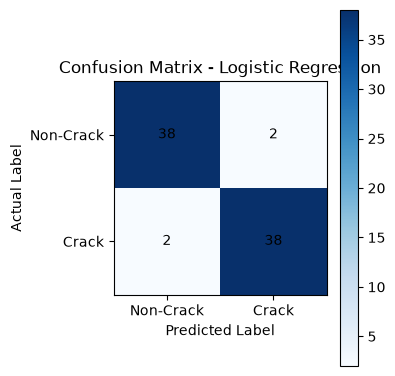


Random Forest
[[39  1]
 [ 1 39]]


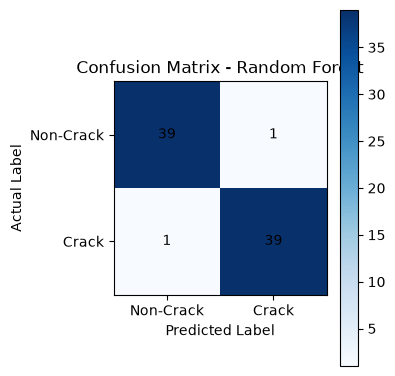


SVM
[[39  1]
 [ 1 39]]


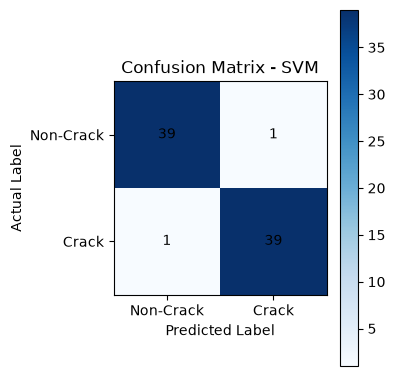

In [41]:
for model_name, cm in confusion_matrices.items():

    print(f"\n{model_name}")
    print(cm)

    plt.figure(figsize=(4, 4))
    plt.imshow(cm, cmap="Blues")

    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")

    plt.xticks([0, 1], ["Non-Crack", "Crack"])
    plt.yticks([0, 1], ["Non-Crack", "Crack"])

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.colorbar()
    plt.tight_layout()
    plt.show()

In [42]:
results_df.to_csv("output/image_model_results.csv", index=False)

print("Image model results saved successfully.")

Image model results saved successfully.


saving confusion matrices


In [43]:
for model_name, cm in confusion_matrices.items():

    plt.figure(figsize=(5, 4))
    plt.imshow(cm, cmap="Blues")

    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")

    plt.xticks([0, 1], ["Non-Crack", "Crack"])
    plt.yticks([0, 1], ["Non-Crack", "Crack"])

    for i in range(2):
        for j in range(2):
            plt.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center"
            )

    plt.colorbar()
    plt.tight_layout()

    filename = model_name.lower().replace(" ", "_") + "_confusion_matrix.png"
    plt.savefig(f"output/{filename}", dpi=300, bbox_inches="tight")
    plt.close()

print("Confusion matrices saved successfully.")

Confusion matrices saved successfully.


In [44]:
import os

print("Files in output folder:")
for file in os.listdir("output"):
    print("-", file)

Files in output folder:
- image_features.csv
- image_model_results.csv
- logistic_regression_confusion_matrix.png
- random_forest_confusion_matrix.png
- sample_canny_edges.png
- sample_grayscale.png
- svm_confusion_matrix.png


In [45]:
results_df

,Model,Accuracy,Precision,Recall,F1-Score,Training Time (s),Prediction Time (s)
0,Logistic Regression,0.950,0.950,0.950,0.950,0.013001,0.000489
1,Random Forest,0.975,0.975,0.975,0.975,0.116671,0.007245
2,SVM,0.975,0.975,0.975,0.975,0.002570,0.000614


In [47]:
import os

print(os.listdir("dataset"))

['Crack', 'emails.csv', 'Non-Crack']


In [48]:
for file in os.listdir("dataset"):
    print(file)

Crack
emails.csv
Non-Crack


In [49]:
import glob
import os

csv_files = glob.glob("dataset/*.csv")

print("CSV files found:")
for file in csv_files:
    print(file)

CSV files found:
dataset\emails.csv


In [50]:
email_df = pd.read_csv(csv_files[0])

print("Dataset shape:", email_df.shape)
print("\nColumns:")
print(email_df.columns.tolist())

Dataset shape: (5172, 3002)

Columns:
['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou', 'in', 'on', 'is', 'this', 'enron', 'i', 'be', 'that', 'will', 'have', 'with', 'your', 'at', 'we', 's', 'are', 'it', 'by', 'com', 'as', 'from', 'gas', 'or', 'not', 'me', 'deal', 'if', 'meter', 'hpl', 'please', 're', 'e', 'any', 'our', 'corp', 'can', 'd', 'all', 'has', 'was', 'know', 'need', 'an', 'forwarded', 'new', 't', 'may', 'up', 'j', 'mmbtu', 'should', 'do', 'am', 'get', 'out', 'see', 'no', 'there', 'price', 'daren', 'but', 'been', 'company', 'l', 'these', 'let', 'so', 'would', 'm', 'into', 'xls', 'farmer', 'attached', 'us', 'information', 'they', 'message', 'day', 'time', 'my', 'one', 'what', 'only', 'http', 'th', 'volume', 'mail', 'contract', 'which', 'month', 'more', 'robert', 'sitara', 'about', 'texas', 'nom', 'energy', 'pec', 'questions', 'www', 'deals', 'volumes', 'pm', 'ena', 'now', 'their', 'file', 'some', 'email', 'just', 'also', 'call', 'change', 'other', 'here',

In [51]:
email_df.head()

email_df.info()

print(email_df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 5172 entries, 0 to 5171
Columns: 3002 entries, Email No. to Prediction
dtypes: int64(3001), str(1)
memory usage: 118.5 MB
(5172, 3002)


In [52]:
email_df["label"].value_counts()

KeyError: 'label'

In [53]:
print("Dataset shape:", email_df.shape)

print("\nColumn names:")
print(email_df.columns.tolist())

print("\nFirst 5 rows:")
display(email_df.head())

Dataset shape: (5172, 3002)

Column names:
['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou', 'in', 'on', 'is', 'this', 'enron', 'i', 'be', 'that', 'will', 'have', 'with', 'your', 'at', 'we', 's', 'are', 'it', 'by', 'com', 'as', 'from', 'gas', 'or', 'not', 'me', 'deal', 'if', 'meter', 'hpl', 'please', 're', 'e', 'any', 'our', 'corp', 'can', 'd', 'all', 'has', 'was', 'know', 'need', 'an', 'forwarded', 'new', 't', 'may', 'up', 'j', 'mmbtu', 'should', 'do', 'am', 'get', 'out', 'see', 'no', 'there', 'price', 'daren', 'but', 'been', 'company', 'l', 'these', 'let', 'so', 'would', 'm', 'into', 'xls', 'farmer', 'attached', 'us', 'information', 'they', 'message', 'day', 'time', 'my', 'one', 'what', 'only', 'http', 'th', 'volume', 'mail', 'contract', 'which', 'month', 'more', 'robert', 'sitara', 'about', 'texas', 'nom', 'energy', 'pec', 'questions', 'www', 'deals', 'volumes', 'pm', 'ena', 'now', 'their', 'file', 'some', 'email', 'just', 'also', 'call', 'change', 'other', 'h

,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0


In [54]:
import glob
import os

csv_files = glob.glob("dataset/*.csv")

print("CSV files found:")
for file in csv_files:
    print(file)

CSV files found:
dataset\emails.csv


In [56]:
email_df = pd.read_csv(csv_files[0])

print("Dataset shape:", email_df.shape)
print("\nColumns:")
print(email_df.columns.tolist())
email_df.head()

Dataset shape: (5172, 3002)

Columns:
['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou', 'in', 'on', 'is', 'this', 'enron', 'i', 'be', 'that', 'will', 'have', 'with', 'your', 'at', 'we', 's', 'are', 'it', 'by', 'com', 'as', 'from', 'gas', 'or', 'not', 'me', 'deal', 'if', 'meter', 'hpl', 'please', 're', 'e', 'any', 'our', 'corp', 'can', 'd', 'all', 'has', 'was', 'know', 'need', 'an', 'forwarded', 'new', 't', 'may', 'up', 'j', 'mmbtu', 'should', 'do', 'am', 'get', 'out', 'see', 'no', 'there', 'price', 'daren', 'but', 'been', 'company', 'l', 'these', 'let', 'so', 'would', 'm', 'into', 'xls', 'farmer', 'attached', 'us', 'information', 'they', 'message', 'day', 'time', 'my', 'one', 'what', 'only', 'http', 'th', 'volume', 'mail', 'contract', 'which', 'month', 'more', 'robert', 'sitara', 'about', 'texas', 'nom', 'energy', 'pec', 'questions', 'www', 'deals', 'volumes', 'pm', 'ena', 'now', 'their', 'file', 'some', 'email', 'just', 'also', 'call', 'change', 'other', 'here',

,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0


In [3]:
import pandas as pd
import os

csv_files = [f for f in os.listdir("dataset") if f.endswith(".csv")]
print(csv_files)

['emails.csv']


In [5]:
email_df = pd.read_csv("dataset/emails.csv")

print("Dataset shape:", email_df.shape)
print(email_df.head())

email_df["Prediction"].value_counts()

Dataset shape: (5172, 3002)
  Email No.  the  to  ect  and  for  of    a  you  hou  ...  connevey  jay  \
0   Email 1    0   0    1    0    0   0    2    0    0  ...         0    0   
1   Email 2    8  13   24    6    6   2  102    1   27  ...         0    0   
2   Email 3    0   0    1    0    0   0    8    0    0  ...         0    0   
3   Email 4    0   5   22    0    5   1   51    2   10  ...         0    0   
4   Email 5    7   6   17    1    5   2   57    0    9  ...         0    0   

   valued  lay  infrastructure  military  allowing  ff  dry  Prediction  
0       0    0               0         0         0   0    0           0  
1       0    0               0         0         0   1    0           0  
2       0    0               0         0         0   0    0           0  
3       0    0               0         0         0   0    0           0  
4       0    0               0         0         0   1    0           0  

[5 rows x 3002 columns]


Prediction
0    3672
1    1500
Name: count, dtype: int64

In [6]:

X = email_df.drop(columns=["Email No.", "Prediction"])
y = email_df["Prediction"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (5172, 3000)
Target shape: (5172,)


Train/Test Split

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (4137, 3000)
Testing data: (1035, 3000)


Train Logistic Regression

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time

# Create the model
logistic_model = LogisticRegression(max_iter=1000, random_state=42)

# Training time
start_train = time.perf_counter()
logistic_model.fit(X_train, y_train)
train_time = time.perf_counter() - start_train

# Prediction time
start_pred = time.perf_counter()
y_pred_lr = logistic_model.predict(X_test)
prediction_time = time.perf_counter() - start_pred

# Evaluation
accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)
print("Training Time:", train_time, "seconds")
print("Prediction Time:", prediction_time, "seconds")

Logistic Regression Results
---------------------------
Accuracy: 0.9826086956521739
Precision: 0.9577922077922078
Recall: 0.9833333333333333
F1-Score: 0.9703947368421053
Training Time: 9.344917799986433 seconds
Prediction Time: 0.06132839998463169 seconds


Naive Bayes

In [9]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time

# Create the model
nb_model = MultinomialNB()

# Training time
start_train = time.perf_counter()
nb_model.fit(X_train, y_train)
train_time_nb = time.perf_counter() - start_train

# Prediction time
start_pred = time.perf_counter()
y_pred_nb = nb_model.predict(X_test)
prediction_time_nb = time.perf_counter() - start_pred

# Evaluation
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

print("Naive Bayes Results")
print("-------------------")
print("Accuracy:", accuracy_nb)
print("Precision:", precision_nb)
print("Recall:", recall_nb)
print("F1-Score:", f1_nb)
print("Training Time:", train_time_nb, "seconds")
print("Prediction Time:", prediction_time_nb, "seconds")

Naive Bayes Results
-------------------
Accuracy: 0.9420289855072463
Precision: 0.8680981595092024
Recall: 0.9433333333333334
F1-Score: 0.9041533546325878
Training Time: 0.1648517000139691 seconds
Prediction Time: 0.13952729996526614 seconds


Random Forest

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time

# Create the model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Training time
start_train = time.perf_counter()
rf_model.fit(X_train, y_train)
train_time_rf = time.perf_counter() - start_train

# Prediction time
start_pred = time.perf_counter()
y_pred_rf = rf_model.predict(X_test)
prediction_time_rf = time.perf_counter() - start_pred

# Evaluation
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print("Accuracy:", accuracy_rf)
print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("F1-Score:", f1_rf)
print("Training Time:", train_time_rf, "seconds")
print("Prediction Time:", prediction_time_rf, "seconds")

Random Forest Results
---------------------
Accuracy: 0.9642512077294686
Precision: 0.933993399339934
Recall: 0.9433333333333334
F1-Score: 0.9386401326699834
Training Time: 1.048526500002481 seconds
Prediction Time: 0.13478089997079223 seconds


creating the comparison table

In [ ]:
email_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        accuracy_nb,
        accuracy_rf
    ],
    "Precision": [
        precision,
        precision_nb,
        precision_rf
    ],
    "Recall": [
        recall,
        recall_nb,
        recall_rf
    ],
    "F1-Score": [
        f1,
        f1_nb,
        f1_rf
    ],
    "Training Time (s)": [
        train_time,
        train_time_nb,
        train_time_rf
    ],
    "Prediction Time (s)": [
        prediction_time,
        prediction_time_nb,
        prediction_time_rf
    ]
})

email_results

email_results.to_csv(
    "output/email_model_results.csv",
    index=False
)

print("Email model results saved successfully.")

Email model results saved successfully.


Confusion Matrices

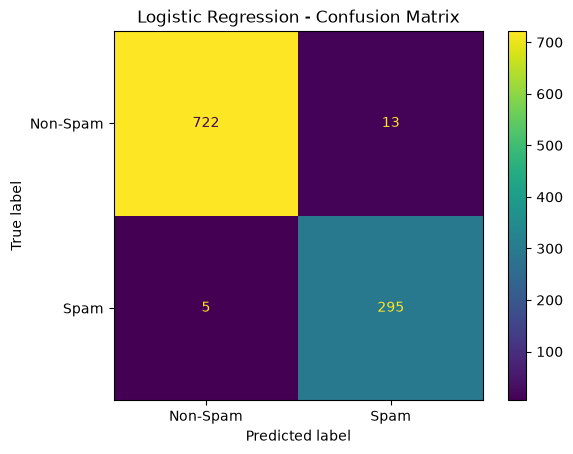

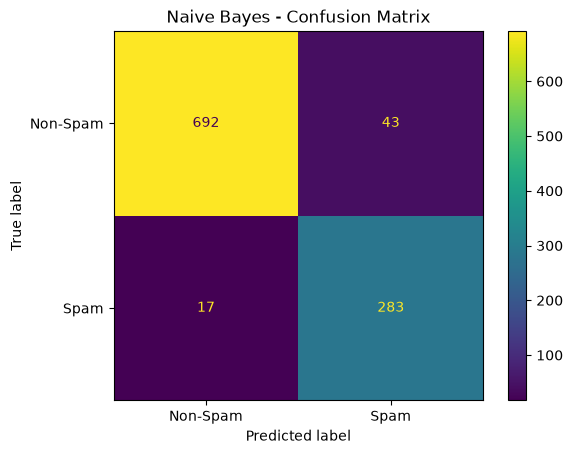

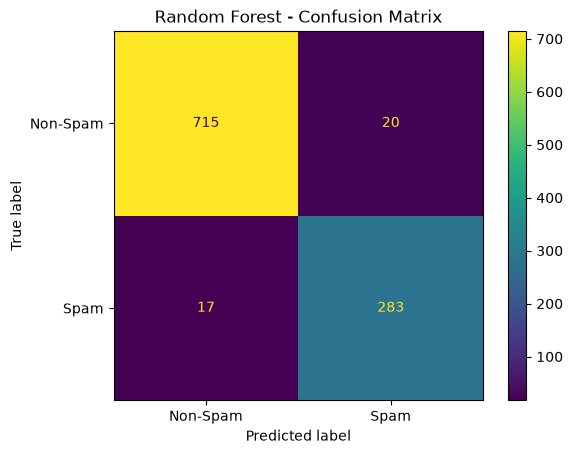

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)

disp_lr = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=["Non-Spam", "Spam"]
)

disp_lr.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()


# Naive Bayes
cm_nb = confusion_matrix(y_test, y_pred_nb)

disp_nb = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=["Non-Spam", "Spam"]
)

disp_nb.plot()
plt.title("Naive Bayes - Confusion Matrix")
plt.show()


# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Non-Spam", "Spam"]
)

disp_rf.plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()

In [13]:
plt.figure()
disp_lr.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.savefig("output/confusion_matrix_logistic_regression.png", bbox_inches="tight")
plt.close()

# Save Naive Bayes confusion matrix
plt.figure()
disp_nb.plot()
plt.title("Naive Bayes - Confusion Matrix")
plt.savefig("output/confusion_matrix_naive_bayes.png", bbox_inches="tight")
plt.close()

# Save Random Forest confusion matrix
plt.figure()
disp_rf.plot()
plt.title("Random Forest - Confusion Matrix")
plt.savefig("output/confusion_matrix_random_forest.png", bbox_inches="tight")
plt.close()

print("All confusion matrices saved successfully.")

All confusion matrices saved successfully.


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

Part C: Improve the Email Model

In [14]:
from sklearn.feature_selection import SelectKBest, chi2

# Select the 1500 most informative features
selector = SelectKBest(score_func=chi2, k=1500)

# Fit only on training data
X_train_selected = selector.fit_transform(X_train, y_train)

# Apply the same selection to test data
X_test_selected = selector.transform(X_test)

print("Original number of features:", X_train.shape[1])
print("Reduced number of features:", X_train_selected.shape[1])
print("Training data after feature selection:", X_train_selected.shape)
print("Testing data after feature selection:", X_test_selected.shape)

Original number of features: 3000
Reduced number of features: 1500
Training data after feature selection: (4137, 1500)
Testing data after feature selection: (1035, 1500)


Training the improved Logistic Regression model

In [15]:
# Improved Logistic Regression using 1500 selected features

improved_lr = LogisticRegression(max_iter=1000, random_state=42)

# Training time
start_train = time.perf_counter()
improved_lr.fit(X_train_selected, y_train)
improved_train_time = time.perf_counter() - start_train

# Prediction time
start_pred = time.perf_counter()
y_pred_improved = improved_lr.predict(X_test_selected)
improved_prediction_time = time.perf_counter() - start_pred

# Evaluation
improved_accuracy = accuracy_score(y_test, y_pred_improved)
improved_precision = precision_score(y_test, y_pred_improved)
improved_recall = recall_score(y_test, y_pred_improved)
improved_f1 = f1_score(y_test, y_pred_improved)

print("Improved Logistic Regression Results")
print("------------------------------------")
print("Accuracy:", improved_accuracy)
print("Precision:", improved_precision)
print("Recall:", improved_recall)
print("F1-Score:", improved_f1)
print("Training Time:", improved_train_time, "seconds")
print("Prediction Time:", improved_prediction_time, "seconds")

Improved Logistic Regression Results
------------------------------------
Accuracy: 0.9758454106280193
Precision: 0.9537953795379538
Recall: 0.9633333333333334
F1-Score: 0.9585406301824212
Training Time: 5.72735369997099 seconds
Prediction Time: 0.008021100016776472 seconds


In [16]:
# Part C: Original vs Improved Model

improvement_results = pd.DataFrame({
    "Model": [
        "Original Logistic Regression",
        "Improved Logistic Regression"
    ],
    "Features": [
        X_train.shape[1],
        X_train_selected.shape[1]
    ],
    "Accuracy": [
        accuracy,
        improved_accuracy
    ],
    "Precision": [
        precision,
        improved_precision
    ],
    "Recall": [
        recall,
        improved_recall
    ],
    "F1-Score": [
        f1,
        improved_f1
    ],
    "Training Time (s)": [
        train_time,
        improved_train_time
    ],
    "Prediction Time (s)": [
        prediction_time,
        improved_prediction_time
    ]
})

improvement_results

,Model,Features,Accuracy,Precision,Recall,F1-Score,Training Time (s),Prediction Time (s)
0,Original Logistic Regression,3000,0.982609,0.957792,0.983333,0.970395,9.344918,0.061328
1,Improved Logistic Regression,1500,0.975845,0.953795,0.963333,0.958541,5.727354,0.008021


In [17]:
improvement_results.to_csv(
    "output/email_improvement_results.csv",
    index=False
)

print("Part C results saved successfully.")

Part C results saved successfully.


Model performance comparison graph

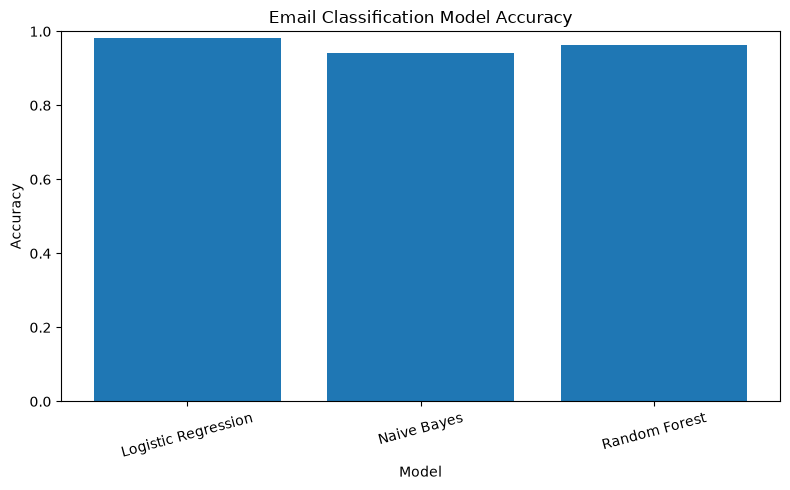

In [18]:
import matplotlib.pyplot as plt

# Accuracy comparison
plt.figure(figsize=(8, 5))

plt.bar(
    email_results["Model"],
    email_results["Accuracy"]
)

plt.title("Email Classification Model Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(
    "output/email_model_accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

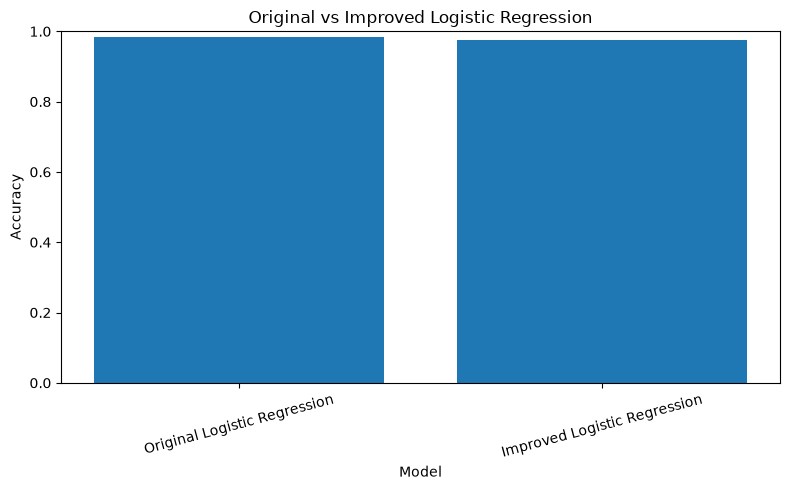

In [19]:
plt.figure(figsize=(8, 5))

plt.bar(
    improvement_results["Model"],
    improvement_results["Accuracy"]
)

plt.title("Original vs Improved Logistic Regression")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(
    "output/email_improvement_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
import os

print("Files in output folder:")
print("-----------------------")

for file in sorted(os.listdir("output")):
    print(file)

Files in output folder:
-----------------------
confusion_matrix_logistic_regression.png
confusion_matrix_naive_bayes.png
confusion_matrix_random_forest.png
email_improvement_comparison.png
email_improvement_results.csv
email_model_accuracy_comparison.png
email_model_results.csv
image_features.csv
image_model_results.csv
logistic_regression_confusion_matrix.png
random_forest_confusion_matrix.png
sample_canny_edges.png
sample_grayscale.png
svm_confusion_matrix.png
